# Car Price Prediction Using Machine Learning

## Oasis Infobyte Data Science Internship - Task 3



## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load dataset

In [2]:
df = pd.read_csv("C:/Users/bhanu/OneDrive/Desktop/OIBSIP/task_3/car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Check Dataset Information

In [3]:
df.shape

(301, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Checking missing values

In [6]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

## Check duplicate Values

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df = df.drop_duplicates()

## Create Car Age Column

In [11]:
df = df.copy()

df["Car_Age"] = 2018 - df["Year"]

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4


## Drop Car Name Column

In [13]:
df = df.drop("Car_Name", axis=1)

## Convert Categorical Columns into Numbers

In [14]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,4,False,True,False,True
1,2013,4.75,9.54,43000,0,5,True,False,False,True
2,2017,7.25,9.85,6900,0,1,False,True,False,True
3,2011,2.85,4.15,5200,0,7,False,True,False,True
4,2014,4.60,6.87,42450,0,4,True,False,False,True


## Check Correlation

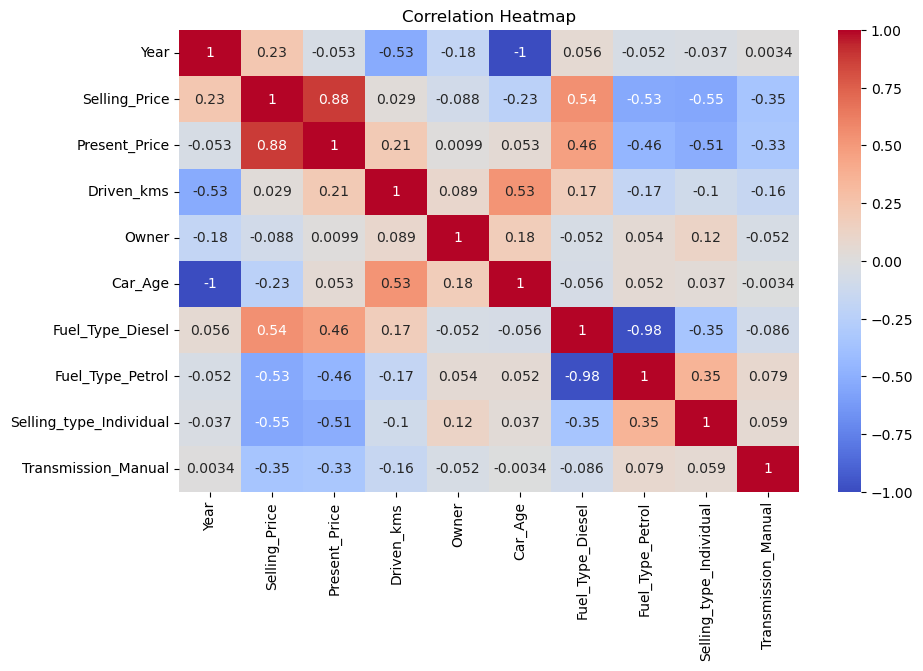

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Select Features and Target

In [16]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

## Split Data into Training and Testing

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Linear Regression Model

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Make Predictions

In [19]:
y_pred = model.predict(X_test)
y_pred

array([ 7.50049519,  7.791134  ,  1.36525272,  7.00895369, 11.16501084,
        4.53381705,  8.49154086,  1.69915065,  8.82263182, -0.96326043,
       10.31787191, -0.97056227,  0.72346986,  1.5342333 ,  4.97295184,
        5.04459165,  1.2926896 ,  1.85007481, 21.5644582 ,  0.86611161,
        0.92951326,  2.44919214,  5.58016408,  0.26457568,  6.26693473,
        7.82233882,  8.68146089,  1.17319762,  4.84502493,  4.91995973,
        3.26495865,  5.48547433,  6.27517695,  2.75742504,  2.90320874,
        6.96789402,  1.26301663, -4.98759108,  1.37752814, 10.38798971,
        7.10369319,  9.03962134,  1.62594283,  4.02100293,  0.97360559,
       -2.14139679,  8.14295502,  4.3744243 ,  5.65092383, -0.59580701,
        0.66085013,  0.20426306, 10.20128223,  9.4526807 ,  7.29844635,
        6.25392698,  3.71576708,  3.43085155,  9.56250205,  9.15970379])

## Evaluate the Model

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 1.472545750817769
Mean Squared Error: 6.373125106262017
Root Mean Squared Error: 2.5245049230021355
R2 Score: 0.7527233824219978


## Actual vs Predicted Values

In [21]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
283,8.99,7.500495
267,8.35,7.791134
166,0.45,1.365253
9,7.45,7.008954
78,5.25,11.165011
280,5.25,4.533817
95,5.85,8.491541
111,1.15,1.699151
5,9.25,8.822632
175,0.38,-0.963260


## Visualize Actual vs Predicted Prices

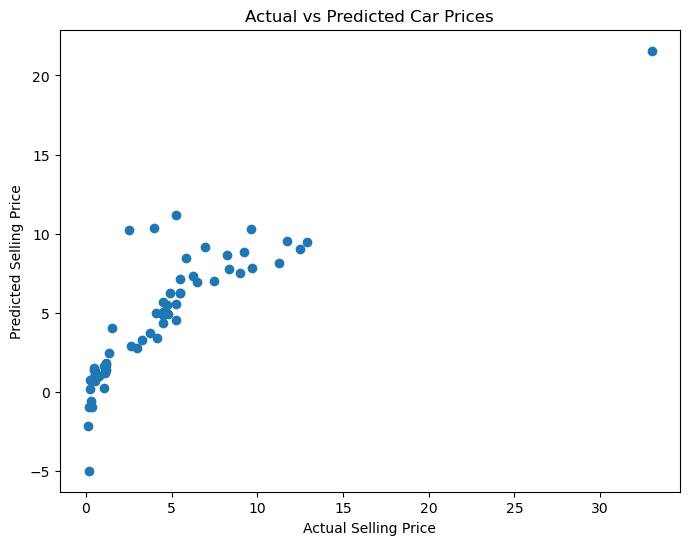

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

## Regression Line Plot

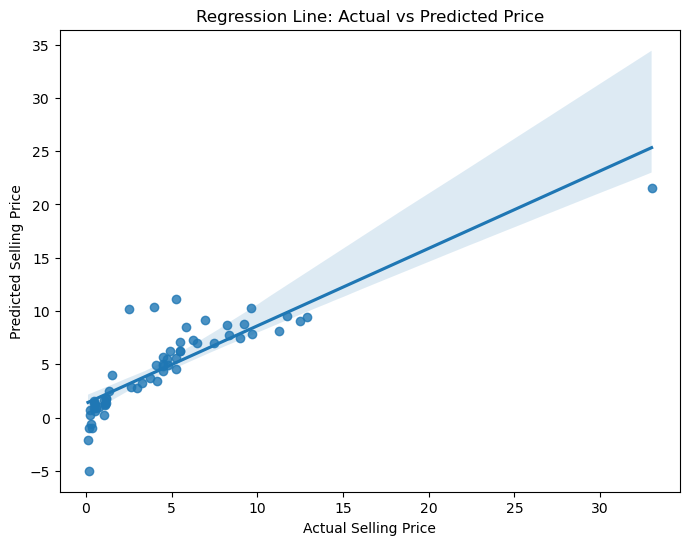

In [23]:
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Regression Line: Actual vs Predicted Price")
plt.show()

# Decision Tree Model

In [25]:
from sklearn.tree import DecisionTreeRegressor

## Create and Train the Model

In [26]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Make Predictions

In [27]:
dt_pred = dt_model.predict(X_test)

dt_pred

array([ 7.25,  9.5 ,  0.45,  5.95,  9.25,  5.3 ,  7.45,  1.2 ,  7.25,
        0.15,  9.25,  0.25,  0.27,  0.48,  4.75,  5.65,  0.6 ,  1.1 ,
       23.  ,  0.6 ,  0.6 ,  3.  ,  5.8 ,  1.95,  7.9 ,  8.65,  8.55,
        1.1 ,  4.5 ,  5.  ,  4.  ,  4.4 ,  7.9 ,  2.7 ,  4.  ,  6.5 ,
        1.15,  0.1 ,  1.1 ,  9.25,  5.2 ,  8.55,  1.05,  3.6 ,  0.6 ,
        0.2 ,  9.15,  5.3 ,  4.4 ,  0.15,  0.65,  0.3 ,  9.25, 10.25,
        8.5 ,  8.25,  3.1 ,  3.9 , 11.25,  7.05])

## Evaluate Decision Tree Model

In [29]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Mean Absolute Error:", dt_mae)
print("Decision Tree Mean Squared Error:", dt_mse)
print("Decision Tree Root Mean Squared Error:", dt_rmse)
print("Decision Tree R2 Score:", dt_r2)

Decision Tree Mean Absolute Error: 1.1488333333333332
Decision Tree Mean Squared Error: 4.546031666666667
Decision Tree Root Mean Squared Error: 2.1321425061816734
Decision Tree R2 Score: 0.8236144253889992


## Compare Actual vs Predicted Prices

In [30]:
dt_results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": dt_pred
})

dt_results.head(10)

,Actual Price,Predicted Price
283,8.99,7.25
267,8.35,9.50
166,0.45,0.45
9,7.45,5.95
78,5.25,9.25
280,5.25,5.30
95,5.85,7.45
111,1.15,1.20
5,9.25,7.25
175,0.38,0.15


## Visualize Actual vs Predicted Prices

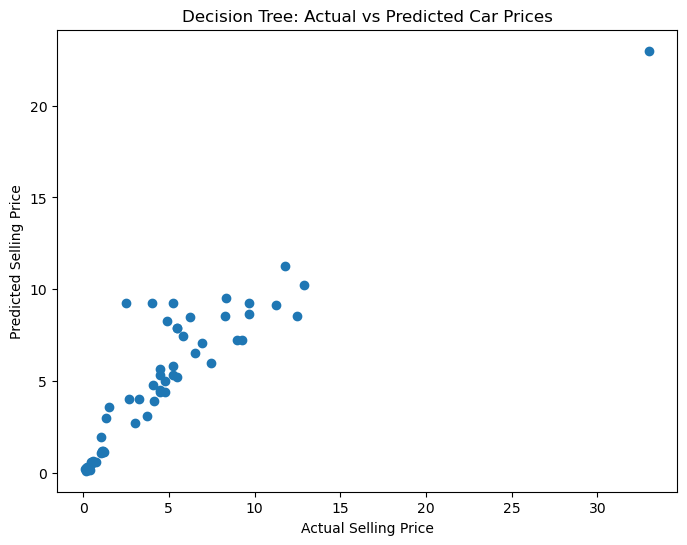

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, dt_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Decision Tree: Actual vs Predicted Car Prices")
plt.show()

## Decision Tree Regressor

After training the Linear Regression model, I also used a Decision Tree Regressor to compare the performance. Decision Tree is a supervised machine learning algorithm that can capture non-linear relationships between car features and selling price. This helps us check whether a tree-based model performs better than a simple linear model.

## Compare Linear Regression and Decision Tree

In [34]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regressor"],
    "MAE": [mae, dt_mae],
    "RMSE": [rmse, dt_rmse],
    "R2 Score": [r2, dt_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.472546,2.524505,0.752723
1,Decision Tree Regressor,1.148833,2.132143,0.823614


## Visualize Model Comparison

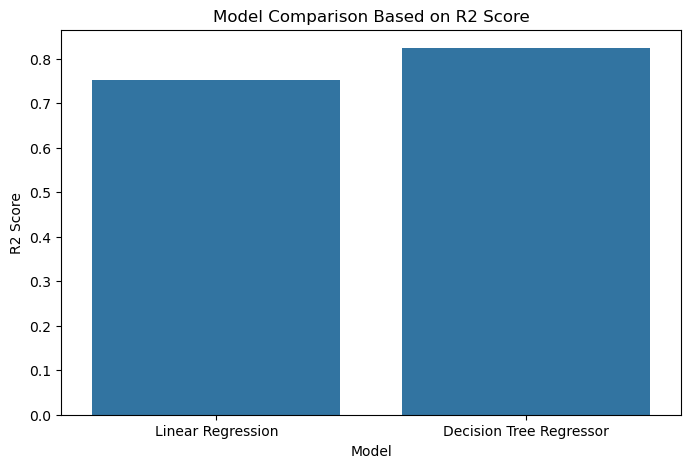

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=comparison)
plt.title("Model Comparison Based on R2 Score")
plt.show()

## Model Comparison

Both Linear Regression and Decision Tree Regressor were tested for car price prediction. The models were evaluated using MAE, RMSE, and R2 Score. The model with lower error values and higher R2 Score gives better prediction performance.